# 03 - Análise exploratória (EDA)

Notebook responsável pela análise exploratória dos dados limpos em
`data/processed/`: estatísticas descritivas, correlações entre variáveis
climáticas e produção cafeeira, e geração de gráficos exploratórios
(salvos em `figuras/`).

Usa as funções de `src/risco.py`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/lavras_clima_limpo.csv")
df.shape

(18628, 4)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18628 entries, 0 to 18627
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   time                18628 non-null  str    
 1   temperature_2m_max  18628 non-null  float64
 2   temperature_2m_min  18628 non-null  float64
 3   precipitation_sum   18628 non-null  float64
dtypes: float64(3), str(1)
memory usage: 764.2 KB


In [3]:
df.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,1974-01-01,25.1,19.3,24.6
1,1974-01-02,25.6,18.7,10.4
2,1974-01-03,26.4,18.4,0.0
3,1974-01-04,26.2,18.2,0.3
4,1974-01-05,26.8,17.7,2.5


In [4]:
df.tail()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
18623,2024-12-27,22.4,19.1,24.9
18624,2024-12-28,25.7,18.3,12.9
18625,2024-12-29,24.3,17.8,28.7
18626,2024-12-30,26.3,17.4,8.8
18627,2024-12-31,26.4,16.5,6.3


In [5]:
df.describe()

,temperature_2m_max,temperature_2m_min,precipitation_sum
count,18628.000000,18628.000000,18628.000000
mean,24.905943,15.369809,3.383552
std,2.962859,3.121473,6.839556
min,11.300000,1.500000,0.000000
25%,23.000000,13.200000,0.000000
50%,25.100000,16.100000,0.200000
75%,27.000000,17.900000,3.800000
max,36.400000,22.100000,90.600000


## Observações iniciais

1. **Temperatura mínima tem uma cauda fria acentuada**: a média da mínima
   diária é ~15,4°C (plausível para Lavras, que fica a ~900m de
   altitude), mas o valor mínimo absoluto é **1,5°C** — bem mais baixo que
   os 3,1°C observados no recorte anterior de 25 anos (2000-2024). Já é
   um indício de que ampliar a janela temporal para 1974-2024 ajuda a
   capturar mais extremos, mesmo numa fonte de reanálise em grade (ver
   Índices de risco climático abaixo).
2. **Chuva é muito assimétrica (skewed)**: a mediana de precipitação
   diária é de apenas 0,2mm, bem abaixo da média de 3,4mm, e o máximo
   chega a 90,6mm em um único dia. Isso mostra que a maior parte dos
   dias é seca, com poucos eventos de chuva intensa puxando a média
   para cima — típico do regime de chuvas concentradas em Lavras.

## Índices de risco climático

Usando as funções de `src/risco.py`, calculamos indicadores de risco relevantes para a cafeicultura: dias de geada (leve/severa), dias de chuva excessiva e ocorrências de veranico (sequência de dias secos dentro da estação chuvosa, out-mar).

In [6]:
import sys
sys.path.append("..")

from src.risco import resumo_anual_risco, contar_sequencias_secas

df["time"] = pd.to_datetime(df["time"])

In [7]:
resumo = resumo_anual_risco(df)
resumo

,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
1974,0,0,0,0
1975,0,0,0,0
1976,0,0,0,1
1977,0,0,0,2
1978,0,0,1,2
1979,1,0,1,1
1980,0,0,2,3
1981,1,0,0,1
1982,0,0,0,1


**Nota sobre geada (limitação de fonte, decisão registrada)**: com o limiar de geada leve (≤3°C) e a janela ampliada de 1974-2024, o Open-Meteo já classifica alguns dias como geada — **4 dias em 3 anos (1979, 1981, 1994)**, mínima absoluta de 1,5°C. É mais informativo que o recorte anterior de 25 anos (2000-2024), que não pegava nenhum — mas ainda é pouco: é uma limitação da fonte Open-Meteo (dado de modelo/reanálise em grade, não estação terrestre local), que tende a suavizar extremos mesmo numa janela mais longa.

Investigamos a alternativa: existe uma estação convencional real do INMET em Lavras, no campus da UFLA (código 83687, operando desde 1911, coordenadas quase idênticas às usadas aqui). Não há estação automática do INMET na cidade (a mais próxima é Varginha, ~55km, desde 2006). O acesso à série histórica da estação 83687, porém, é feito exclusivamente pelo BDMEP do INMET, que exige criar conta — decidimos não seguir por esse caminho nesta fase do projeto. Vale registrar também um alerta da própria UFLA (responsável pela estação, em convênio com o INMET): a série de Lavras tem bastante falha de dados mesmo na fonte original.

**Decisão**: mantemos o Open-Meteo como fonte única nesta fase e tratamos a subestimação de geada como uma limitação conhecida e documentada da pesquisa, não como um bug a corrigir agora. Retomar com dados de estação real (BDMEP ou outra rede) fica como possível trabalho futuro.

**Atualização (2026-08-16): tentativa de destravar a via BDMEP/INMET.** Depois da decisão acima, chegamos a criar conta no BDMEP e solicitar a exportação da série da estação 83687 — mas o e-mail com o CSV nunca chegou. Hoje tentamos duas alternativas para não ficar bloqueados esperando essa resposta:

1. Acessar a API pública (`apitempo.inmet.gov.br`) e o portal de dados históricos do INMET diretamente — ambos recusaram a conexão em toda tentativa (reset de conexão / erro 502), então não são uma via viável hoje.
2. Testar se um modelo de reanálise de grade mais fina no próprio Open-Meteo (ERA5-Land, ~9 km, contra o ERA5/`best_match` usado até aqui, ~25-31 km) captura geada que o modelo atual suaviza. Usamos como referência um evento real e bem documentado: a geada histórica de julho/2021 no Sul de Minas.

In [8]:
import requests

params_base = {
    "latitude": -21.24,
    "longitude": -44.99,
    "start_date": "2021-07-15",
    "end_date": "2021-07-31",
    "daily": "temperature_2m_min",
    "timezone": "America/Sao_Paulo",
}

resp_era5 = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params_base)
resp_era5_land = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={**params_base, "models": "era5_land"},
)

comparacao_modelos = pd.DataFrame({
    "data": resp_era5.json()["daily"]["time"],
    "tmin_era5": resp_era5.json()["daily"]["temperature_2m_min"],
    "tmin_era5_land": resp_era5_land.json()["daily"]["temperature_2m_min"],
})
print("Mínima ERA5:", comparacao_modelos["tmin_era5"].min(), "°C")
print("Mínima ERA5-Land:", comparacao_modelos["tmin_era5_land"].min(), "°C")
comparacao_modelos


Mínima ERA5: 3.7 °C
Mínima ERA5-Land: 4.9 °C


,data,tmin_era5,tmin_era5_land
0,2021-07-15,9.7,9.7
1,2021-07-16,11.4,11.2
2,2021-07-17,12.1,11.7
3,2021-07-18,13.6,15.4
4,2021-07-19,8.1,9.0
5,2021-07-20,3.7,6.5
6,2021-07-21,8.0,9.0
7,2021-07-22,10.1,10.4
8,2021-07-23,9.3,9.8
9,2021-07-24,9.1,9.3


**Resultado**: mesmo na janela do evento de geada mais citado da década para o Sul de Minas, nenhum dos dois modelos do Open-Meteo chega a 3°C (mínimas na casa de 3,7-4,9°C) — ou seja, trocar o modelo de reanálise não resolve a limitação. Isso é evidência a favor da hipótese original: o problema é a resolução espacial de qualquer dado em grade frente a um evento de geada, que é muito local (topografia, drenagem de ar frio), não um parâmetro de fonte que dê para ajustar via API.

**Decisão (reafirmada)**: com a via INMET/BDMEP indisponível hoje (sem resposta ao pedido de exportação, API e portal fora do ar para acesso automatizado) e a alternativa de modelo não resolvendo o problema, mantemos o Open-Meteo como fonte única nesta fase e fechamos esta investigação. Acesso a dado de estação real segue como trabalho futuro (ver `docs/relatorio.md`), retomado se/quando a exportação do BDMEP responder.

**Atualização 2 (2026-08-16): conseguimos a estação real, afinal.** Enquanto mapeávamos alternativas ao BDMEP, achamos que o repositório do BR-DWGD (usado no teste do ERA5-Land acima) também disponibiliza, à parte da grade interpolada, os **dados brutos de observação por estação** que foram usados para construir a grade — arquivo leve (`Tmin.npz`, ~113MB, todas as estações do Brasil), sem precisar de conta nem download da grade completa (~7GB). A estação **83687 (Lavras) está nele**, com cobertura de 96,6% no recorte 1974-2024. Coletado em `01_coleta.ipynb` e limpo em `02_limpeza.ipynb` — ver `src/coleta.py::coletar_geada_estacao_83687`.

Isso substitui a fonte de geada (só a de geada — chuva excessiva e veranico continuam com o Open-Meteo, que funciona bem para essas variáveis) sem invalidar a investigação acima: o teste com ERA5-Land seguiu correto em mostrar que **nenhum dado de grade** resolveria isso, e foi justamente essa investigação que nos levou a procurar dado de estação de verdade.

In [9]:
df_geada = pd.read_csv("../data/processed/lavras_geada_estacao_83687_limpo.csv")
df_geada["time"] = pd.to_datetime(df_geada["time"])

df = df.merge(df_geada[["time", "tmin_estacao"]], on="time", how="left")

resumo = resumo_anual_risco(df, tmin_geada=df["tmin_estacao"])
resumo


,geada_leve,geada_severa,chuva_excessiva,veranicos
ano,,,,
1974,0,0,0,0
1975,1,0,0,0
1976,0,0,0,1
1977,0,0,0,2
1978,1,0,1,2
1979,3,0,1,1
1980,0,0,2,3
1981,2,1,0,1
1982,0,0,0,1


**Grade x estação, lado a lado**: no mesmo recorte 1974-2024, o Open-Meteo (grade) classificou 4 dias de geada leve em 3 anos e nenhum severo; a estação real 83687 classificou **10 dias de geada leve em 6 anos**, mais **1 dia de geada severa** (21/07/1981, -0,2°C — a única vez na série inteira que a mínima ficou abaixo de 0°C). A grade não erra por completo — capta os anos mais extremos (1979, 1981, 1994 aparecem nas duas fontes) — mas subestima tanto a frequência quanto a severidade, e nunca chega a detectar o único evento severo da série.

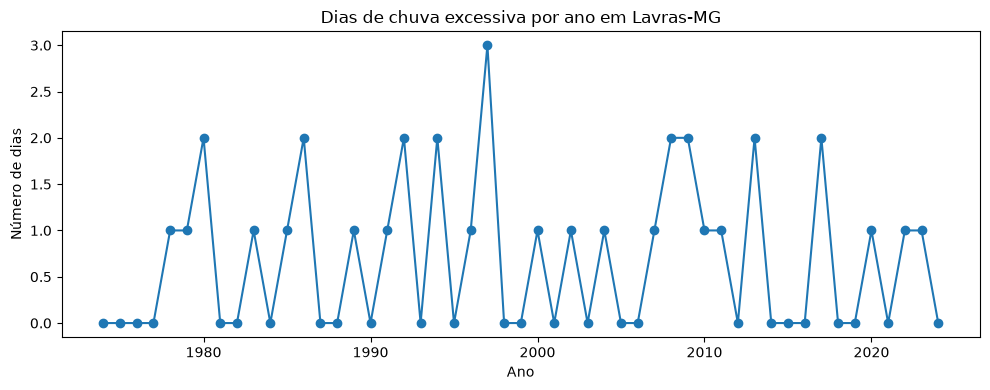

In [10]:
import matplotlib.pyplot as plt

resumo["chuva_excessiva"].plot(marker="o", figsize=(10, 4), title="Dias de chuva excessiva por ano em Lavras-MG")
plt.ylabel("Número de dias")
plt.xlabel("Ano")
plt.tight_layout()
plt.savefig("../figuras/chuva_excessiva_por_ano.png", dpi=150)
plt.show()

### Veranicos

Sequências de pelo menos 10 dias secos consecutivos ocorrendo dentro da estação chuvosa (outubro a março), quando a planta espera chuva regular.

In [11]:
veranicos = contar_sequencias_secas(df)
print("Veranicos detectados:", len(veranicos))
veranicos

Veranicos detectados: 57


,inicio,fim,duracao
0,1976-03-01,1976-03-10,10
1,1977-02-05,1977-03-02,26
2,1977-10-07,1977-10-18,12
3,1978-01-23,1978-02-04,13
4,1978-03-11,1978-03-26,16
5,1979-10-16,1979-10-26,11
6,1980-02-28,1980-03-09,11
7,1980-03-20,1980-03-29,10
8,1980-10-13,1980-10-22,10
9,1981-03-31,1981-04-15,16


## Clima x Produção cafeeira

Pergunta de pesquisa central do projeto: existe correlação histórica entre
os riscos climáticos (geada, chuva excessiva, veranico) e a produtividade
do café em Lavras-MG? Juntamos o resumo anual de risco (`resumo`, acima)
com a série anual de produção do IBGE/SIDRA (`data/processed/lavras_producao_cafe_limpo.csv`)
para investigar.

In [12]:
df_cafe = pd.read_csv("../data/processed/lavras_producao_cafe_limpo.csv")
df_cafe = df_cafe.set_index("ano")

clima_x_producao = resumo.join(df_cafe, how="inner")
clima_x_producao

,geada_leve,geada_severa,chuva_excessiva,veranicos,quantidade_produzida_t,rendimento_medio_kg_ha,area_colhida_ha
ano,,,,,,,
1974,0,0,0,0,2880,2000,1440
1975,1,0,0,0,1197,750,1596
1976,0,0,0,1,3302,1914,1725
1977,0,0,0,2,3120,1600,1950
1978,1,0,1,2,4208,1600,2630
1979,3,0,1,1,4715,1600,2947
1980,0,0,2,3,383,411,930
1981,2,1,0,1,8270,3757,2201
1982,0,0,0,1,1507,807,1868


### Correlação

Usamos correlação de Pearson entre os 4 indicadores de risco climático e
as 3 variáveis de produção. **Ressalva importante**: mesmo com 51 anos
agora (ampliado de 25, depois de descobrir que o IBGE/SIDRA cobre desde
1974), ainda é uma série anual (um ponto por ano) — segue pequena para
conclusões causais fortes, mas já é o dobro do tamanho anterior, o que
ajuda bastante a testar geada de verdade (6 anos com ocorrência, contra
só 1 no recorte anterior).

In [13]:
colunas_risco = ["geada_leve", "geada_severa", "chuva_excessiva", "veranicos"]
colunas_producao = ["area_colhida_ha", "quantidade_produzida_t", "rendimento_medio_kg_ha"]

corr_cruzada = clima_x_producao.corr(method="pearson").loc[colunas_risco, colunas_producao]
corr_cruzada

,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve,-0.251701,0.035241,0.312507
geada_severa,-0.162373,0.260018,0.617101
chuva_excessiva,0.028830,-0.134367,-0.226495
veranicos,-0.005024,-0.060363,-0.091246


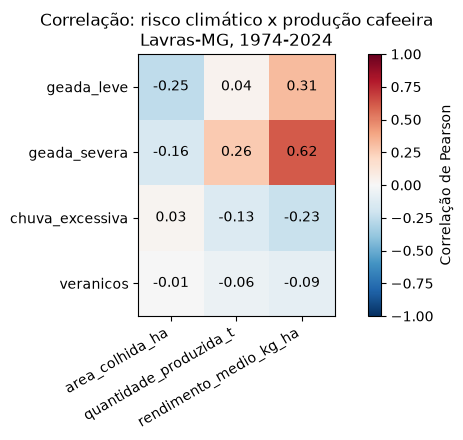

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(corr_cruzada, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(colunas_producao)), labels=colunas_producao, rotation=30, ha="right")
ax.set_yticks(range(len(colunas_risco)), labels=colunas_risco)

for i in range(len(colunas_risco)):
    for j in range(len(colunas_producao)):
        valor = corr_cruzada.iloc[i, j]
        texto = "n/d" if pd.isna(valor) else f"{valor:.2f}"
        ax.text(j, i, texto, ha="center", va="center", color="black")

ax.set_title("Correlação: risco climático x produção cafeeira\nLavras-MG, 1974-2024")
fig.colorbar(im, ax=ax, label="Correlação de Pearson")
plt.tight_layout()
plt.savefig("../figuras/correlacao_risco_producao.png", dpi=150, bbox_inches="tight")
plt.show()

### Leitura dos resultados

- **Geada agora tem uma amostra de verdade**: com 51 anos, a estação
  real registrou geada leve em **6 anos** (1975, 1978, 1979, 1981,
  1994, 2000 — 10 dias no total) e geada severa em **1 ano** (1981, o
  único dia ≤0°C da série inteira: -0,2°C em 21/07/1981). Isso muda o
  quadro de "1 ocorrência" (recorte de 25 anos) para uma amostra que
  já dá para comparar de verdade.
- **A correlação direta é positiva e contraintuitiva** (geada_leve x
  rendimento: r≈+0,31; geada_severa x rendimento: r≈+0,62) — o oposto
  do que a agronomia prevê. Mas comparando os grupos diretamente, isso
  tem uma explicação melhor que coincidência: nos anos com geada leve,
  a **quantidade produzida é praticamente igual** à dos anos sem
  (4.816t vs 4.783t em média) — a diferença está toda na **área
  colhida**, bem menor nos anos de geada (2.568ha vs 3.515ha em
  média). Ou seja, não é que a geada aumentou a produtividade — é que
  4 dos 6 anos de geada desta amostra caem entre 1975 e 1981, no
  início da série, quando a lavoura de Lavras ainda era menor (ver
  tendência de `area_colhida_ha` abaixo). O ano/tamanho da área é o
  fator de confusão, não a geada.
- **A correlação com defasagem conta uma história mais consistente com
  a agronomia** (ver seção seguinte): geada do ano N x produção do ano
  N+1 vira negativa (r≈-0,23 para geada leve, r≈-0,16 para severa) —
  geada prejudicando a safra seguinte, como seria esperado. Ainda
  frágil com n=6, mas aponta na direção certa.
- **Fora a geada, as correlações continuam fracas** (|r| < 0,25 para
  chuva excessiva e veranico). `area_colhida_ha` segue com tendência
  temporal forte (expansão econômica ao longo dos 51 anos), que pode
  confundir qualquer correlação que a envolva — inclusive, como vimos,
  a de geada.

**Conclusão desta fase**: ampliar para 51 anos deu à geada uma amostra
estatisticamente utilizável (6 anos, não 1) — mas a correlação direta
é enganosa por causa da tendência de `area_colhida_ha`. O sinal
defasado (geada de um ano prejudicando o ano seguinte) é mais
plausível, mas ainda fraco demais para afirmar causalidade. Seguimos
sem conseguir demonstrar de forma robusta que clima explica a
variação de produtividade do café em Lavras-MG — mas agora com uma
leitura bem mais rica do porquê.

### Correlação com defasagem (lag)

A correlação acima compara risco climático e produção do **mesmo ano**.
Mas um evento climático pode só afetar a safra do ano seguinte (ex.:
geada/veranico prejudica a floração, e o efeito na colheita aparece
depois). Aqui deslocamos o risco climático um ano para frente: risco do
ano N x produção do ano N+1.

In [15]:
resumo_defasado = resumo.shift(1)
resumo_defasado.columns = [f"{col}_ano_anterior" for col in resumo_defasado.columns]

clima_x_producao_defasada = resumo_defasado.join(df_cafe, how="inner")

colunas_risco_defasado = [f"{col}_ano_anterior" for col in colunas_risco]
corr_defasada = clima_x_producao_defasada.corr(method="pearson").loc[colunas_risco_defasado, colunas_producao]
corr_defasada

,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha
geada_leve_ano_anterior,-0.495084,-0.424446,-0.231718
geada_severa_ano_anterior,-0.220551,-0.250294,-0.162775
chuva_excessiva_ano_anterior,0.026404,0.130855,0.168441
veranicos_ano_anterior,0.056585,0.211855,0.248434


### Comparação por faixas (não linear)

Correlação de Pearson só captura relação **linear**. Como alternativa,
comparamos a produção entre grupos de anos: primeiro por geada
(com/sem geada leve — agora viável com 6 anos positivos), depois pela
mediana de veranicos. Uma relação não linear, ou um efeito mascarado
por um fator de confusão, apareceria aqui mesmo com correlação linear
enganosa.

In [16]:
faixa_geada = clima_x_producao["geada_leve"].gt(0).map({
    True: "com geada leve (>=1 dia)",
    False: "sem geada leve",
})
comparacao_geada = clima_x_producao.groupby(faixa_geada)[colunas_producao].agg(["mean", "count"])
comparacao_geada


area_colhida_ha       quantidade_produzida_t        \
                                    mean count                   mean count   
geada_leve                                                                    
com geada leve (>=1 dia)     2568.333333     6            4816.166667     6   
sem geada leve               3515.488889    45            4783.000000    45   

                         rendimento_medio_kg_ha        
                                           mean count  
geada_leve                                             
com geada leve (>=1 dia)            1844.500000     6  
sem geada leve                      1370.266667    45

In [17]:
mediana_veranicos = clima_x_producao["veranicos"].median()
faixa = clima_x_producao["veranicos"].ge(mediana_veranicos).map({
    True: f"muitos veranicos (>= {mediana_veranicos:.0f})",
    False: f"poucos veranicos (< {mediana_veranicos:.0f})",
})

comparacao_faixas = clima_x_producao.groupby(faixa)[colunas_producao].agg(["mean", "count"])
comparacao_faixas

area_colhida_ha       quantidade_produzida_t        \
                                   mean count                   mean count   
veranicos                                                                    
muitos veranicos (>= 1)     3442.729730    37            4828.297297    37   
poucos veranicos (< 1)      3301.857143    14            4677.500000    14   

                        rendimento_medio_kg_ha        
                                          mean count  
veranicos                                             
muitos veranicos (>= 1)            1426.108108    37  
poucos veranicos (< 1)             1425.928571    14

### Leitura: defasagem e faixas

- **Defasagem confirma o padrão esperado para geada**: `geada_leve_ano_anterior` e `geada_severa_ano_anterior` ficam negativos nas três variáveis de produção (rendimento: r≈-0,23 e r≈-0,16) — geada de um ano associada a produção *menor* no ano seguinte, como a agronomia prevê. Ainda é amostra pequena (6 e 1 anos) para afirmar causalidade, mas é um sinal mais consistente que a correlação direta. Chuva excessiva e veranico defasados continuam fracos (|r| < 0,25).
- **Faixas confirmam a explicação por `area_colhida_ha`**: anos com geada leve têm quantidade produzida praticamente igual à dos anos sem geada (4.816t vs 4.783t), mas área colhida bem menor (2.568ha vs 3.515ha) — daí o rendimento por hectare mais alto nos anos de geada (1.844 vs 1.370 kg/ha, em média) não refletir um efeito real da geada, e sim a área menor típica do início da série, onde caiu a maioria das geadas desta amostra. Veranico não mostra diferença nenhuma entre faixas (rendimento médio ~1.426 kg/ha nos dois grupos, virtualmente idêntico).

**Conclusão consolidada**: com 51 anos em vez de 25, geada deixou de ser um problema de amostra (6 anos com ocorrência, 1 com geada severa) — mas a correlação direta continua enganosa por causa da tendência de `area_colhida_ha`. O sinal mais confiável é o defasado, negativo e consistente com a agronomia, mas ainda estatisticamente frágil. Para chuva excessiva e veranico, nenhuma abordagem (direta, defasada, por faixas) mostrou relação clara com produção. O resultado honesto desta fase é: **não conseguimos demonstrar de forma robusta que clima explica a variação de produtividade do café em Lavras-MG** — mas a expansão da série revelou um sinal de geada defasada que vale a pena investigar com mais rigor estatístico (ex. regressão controlando por área colhida) como próximo passo.